# 2 - Electricity Consumption Forecasting - Time Series

<img src='https://hanelelektrik.com/wp-content/uploads/2024/01/electric_cable_green_1920x800_res_wl2_slider_1920.jpg'>

Bu çalışmada elektrik tüketim verileri üzerinden Prophet yöntemi ile gelecek dönem tüketim değerlerini tahmin edeceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. Zaman serisi görselleştirme
6. Prophet modeli kurma
7. Tahmin
8. Sonuç


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from prophet import Prophet
from prophet.plot import plot_plotly
from sklearn.metrics import mean_absolute_error, mean_squared_error


## 1. Veriyi Yükleme

In [2]:
# Bu bölümde zip dosyasını Google Drive içinden açıp çalışma alanına çıkaracağım.

In [3]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Electricity Consumption Forecast Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]


Mounted at /content/drive


['.config', 'drive', 'electricity_consumption_forecast.csv', 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [4]:
# Bu bölümde csv dosyasını okuyup veri setinin yapısını inceleyeceğim.

In [5]:
df = pd.read_csv('/content/electricity_consumption_forecast.csv')
df.head()


,date,region,consumption_kwh
0,2024-01-01,Marmara,14278
1,2024-01-01,Ege,13942
2,2024-01-01,Akdeniz,12411
3,2024-01-01,İç Anadolu,18975
4,2024-01-01,Karadeniz,20198


In [6]:
df.shape


(2562, 3)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2562 entries, 0 to 2561
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             2562 non-null   object
 1   region           2562 non-null   object
 2   consumption_kwh  2562 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 60.2+ KB


In [8]:
df.isnull().sum()


,0
date,0
region,0
consumption_kwh,0


## 3. Veri Temizleme

In [9]:
# Bu bölümde Prophet için tek bir bölge seçip veri setini temizleyeceğim.

In [10]:
df['date'] = pd.to_datetime(df['date'])
region_df = df[df['region'] == 'Marmara'].copy()
region_df = region_df.sort_values('date')
region_df.head()


,date,region,consumption_kwh
0,2024-01-01,Marmara,14278
7,2024-01-02,Marmara,17512
14,2024-01-03,Marmara,21882
21,2024-01-04,Marmara,14265
28,2024-01-05,Marmara,16396


## 4. Feature Engineering

In [11]:
# Bu bölümde Prophet modelinin istediği ds ve y sütunlarını oluşturacağım.

In [12]:
forecast_df = region_df[['date', 'consumption_kwh']].rename(columns={'date': 'ds', 'consumption_kwh': 'y'})
forecast_df.head()


,ds,y
0,2024-01-01,14278
7,2024-01-02,17512
14,2024-01-03,21882
21,2024-01-04,14265
28,2024-01-05,16396


## 5. Zaman Serisi Görselleştirme

In [13]:
# Bu bölümde seçilen bölgenin zaman içindeki elektrik tüketimini görselleştireceğim.

In [14]:
fig = px.line(forecast_df, x='ds', y='y', title='Marmara Electricity Consumption')
fig.show()


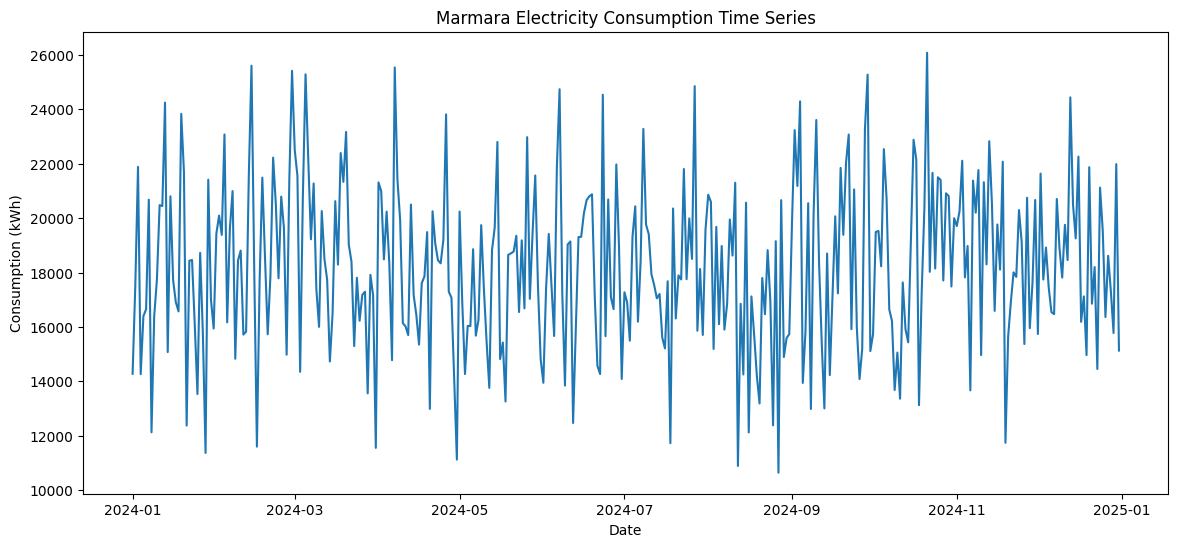

In [15]:
plt.figure(figsize=(14,6))
plt.plot(forecast_df['ds'], forecast_df['y'])
plt.title('Marmara Electricity Consumption Time Series')
plt.xlabel('Date')
plt.ylabel('Consumption (kWh)')
plt.show()


## 6. Prophet Modeli Kurma

In [16]:
# Bu bölümde veri setini train ve test olarak ayırıp Prophet modelini eğitim verisi ile kuracağım.

In [17]:
train = forecast_df[:-30]
test = forecast_df[-30:]

model = Prophet()
model.fit(train)

train.shape, test.shape


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


((336, 2), (30, 2))

## 7. Tahmin

In [18]:
# Bu bölümde test dönemi için tahmin alıp gerçek değerlerle karşılaştıracağım.

In [19]:
future = model.make_future_dataframe(periods=30)
prediction = model.predict(future)
forecast = prediction[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)
forecast


,ds,yhat,yhat_lower,yhat_upper
336,2024-12-02,18413.631570,14688.781683,22070.885178
337,2024-12-03,18150.235252,14256.814097,21891.065705
338,2024-12-04,18696.023763,14842.514337,22689.846399
339,2024-12-05,17887.246919,13891.958103,22032.804585
340,2024-12-06,18217.889222,14403.449974,21835.165408
341,2024-12-07,18326.365912,14517.747944,22495.156075
342,2024-12-08,17980.245581,14247.953751,21816.959845
343,2024-12-09,18417.351550,14724.456144,22074.961630
344,2024-12-10,18153.955233,14443.136068,21994.253930
345,2024-12-11,18699.743743,14600.007196,22472.019370


In [20]:
comparison_df = test.merge(forecast[['ds', 'yhat']], on='ds')
comparison_df.head()


,ds,y,yhat
0,2024-12-02,21636,18413.631570
1,2024-12-03,17741,18150.235252
2,2024-12-04,18918,18696.023763
3,2024-12-05,17459,17887.246919
4,2024-12-06,16547,18217.889222


In [21]:
mae = mean_absolute_error(comparison_df['y'], comparison_df['yhat'])
rmse = np.sqrt(mean_squared_error(comparison_df['y'], comparison_df['yhat']))
print('MAE:', round(mae, 2))
print('RMSE:', round(rmse, 2))


MAE: 1925.49
RMSE: 2393.18


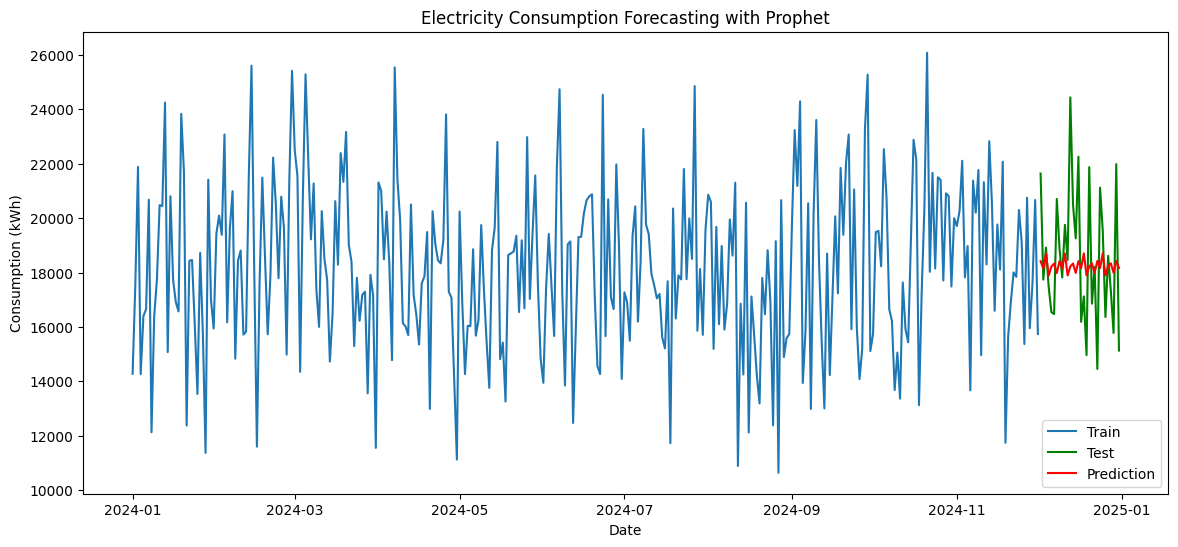

In [22]:
plt.figure(figsize=(14,6))
plt.plot(train['ds'], train['y'], label='Train')
plt.plot(test['ds'], test['y'], label='Test', color='green')
plt.plot(comparison_df['ds'], comparison_df['yhat'], label='Prediction', color='red')
plt.legend()
plt.title('Electricity Consumption Forecasting with Prophet')
plt.xlabel('Date')
plt.ylabel('Consumption (kWh)')
plt.show()


In [23]:
fig = plot_plotly(model, prediction)
fig.show()


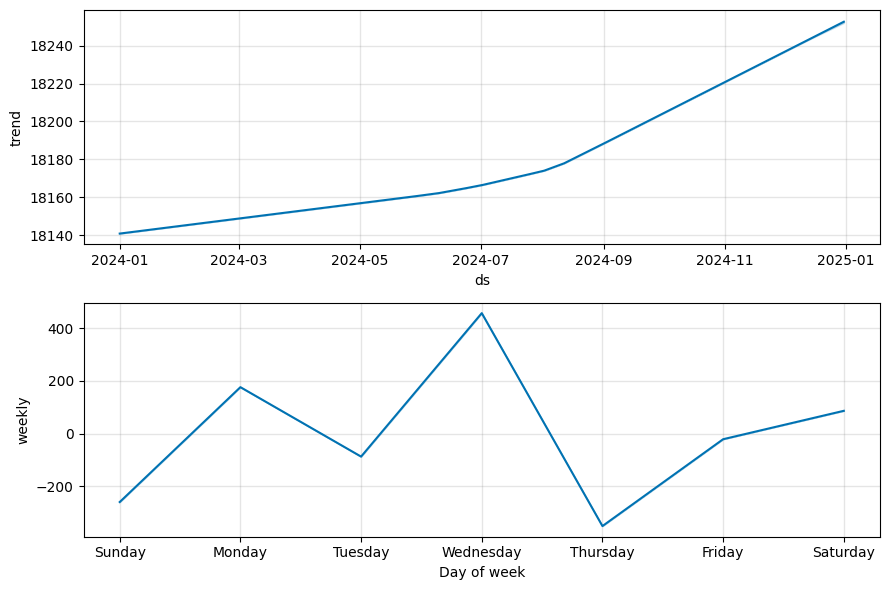

In [24]:
model.plot_components(prediction)
plt.show()


## 8. Sonuç

Bu projede elektrik tüketim tahmini için Prophet tabanlı bir time series modeli kullanıldı. Elde edilen sonuçlara göre model test dönemi için gelecek 30 günlük tüketim değerlerini tahmin etti ve 1925.49 MAE ile 2393.18 RMSE değeri elde etti. Bu sonuç, modelin gerçek tüketim değerlerinden ortalama yaklaşık 1925 kWh sapma ile tahmin yaptığını gösterdi.